In [2]:
import warnings
warnings.simplefilter("ignore")
import numpy as np
import matplotlib.pyplot as plt
from lightkurve import search_lightcurve
from scipy.ndimage import gaussian_filter1d
from astropy.stats import sigma_clip
from scipy.optimize import curve_fit
import batman

# Configurações globais de plotagem
for att in ['axes.labelsize', 'axes.titlesize', 'legend.fontsize', 'xtick.labelsize', 'ytick.labelsize']:
    plt.rcParams[att] = 10

print("="*60)
print("INICIANDO PIPELINE: AU MIC (Planetas b e c)")
print("="*60)

# ============================================================
# PASSO 1 e 2: FUNÇÕES DO MODELO ROTACIONAL (Limpeza da Estrela)
# ============================================================
def gerar_modelo_rotacional_cadencia(t, f, mask_good_flares, cadencia_s=120, janela_horas=10, sigma_clip_val=1.5):
    pontos_por_hora = 3600 / cadencia_s
    janela_pontos = int(janela_horas * pontos_por_hora)
    sigma_pontos = janela_pontos / 8
    
    quebras = list(np.where(np.diff(t) > (20 / (24 * 60)))[0] + 1)
    seg_inicios = [0] + quebras
    seg_fins    = quebras + [len(t)]
    
    modelo_final = np.zeros_like(f)
    
    for i0, i1 in zip(seg_inicios, seg_fins):
        t_seg, f_seg, mask_seg = t[i0:i1], f[i0:i1], mask_good_flares[i0:i1]
        if len(t_seg) < janela_pontos / 4:
            modelo_final[i0:i1] = np.nanmedian(f_seg)
            continue
            
        f_limpo = np.copy(f_seg)
        for _ in range(10):
            temp_smooth = gaussian_filter1d(f_limpo, sigma=sigma_pontos, mode='nearest')
            clipped = sigma_clip(f_seg - temp_smooth, sigma_lower=10.0, sigma_upper=sigma_clip_val, maxiters=1, cenfunc='median', stdfunc='mad_std')            
            f_limpo[clipped.mask] = temp_smooth[clipped.mask]
            f_limpo[~mask_seg] = temp_smooth[~mask_seg] 
            
        modelo_final[i0:i1] = gaussian_filter1d(f_limpo, sigma=sigma_pontos, mode='nearest')
    return modelo_final

def ajustar_trecho_especifico(t, f, mask_good_flares, t_inicio, t_fim, cadencia_s=120, janela_horas=5, sigma_upper=2.0, sigma_lower=2.0, iteracoes=6):
    buffer_dias = (janela_horas * 1.5) / 24.0 
    idx_calc = np.where((t >= t_inicio - buffer_dias) & (t <= t_fim + buffer_dias))[0]
    idx_alvo = np.where((t >= t_inicio) & (t <= t_fim))[0]
    if len(idx_alvo) == 0: return idx_alvo, np.array([])

    t_calc, f_calc, mask_calc = t[idx_calc], f[idx_calc], mask_good_flares[idx_calc]
    sigma_pontos = (janela_horas * (3600 / cadencia_s)) / 8
    f_limpo = np.copy(f_calc)
    
    for _ in range(iteracoes):
        temp_smooth = gaussian_filter1d(f_limpo, sigma=sigma_pontos, mode='reflect')
        clipped = sigma_clip(f_calc - temp_smooth, sigma_lower=sigma_lower, sigma_upper=sigma_upper, maxiters=1, cenfunc='median', stdfunc='mad_std')
        mascara_combinada = (~clipped.mask) & mask_calc
        t_bons, f_bons = t_calc[mascara_combinada], f_limpo[mascara_combinada]
        if len(t_bons) > 2: f_limpo = np.interp(t_calc, t_bons, f_bons)
        else: f_limpo[clipped.mask] = temp_smooth[clipped.mask]
            
    modelo_calc = gaussian_filter1d(f_limpo, sigma=sigma_pontos, mode='nearest')
    return idx_alvo, modelo_calc[np.where(idx_calc == idx_alvo[0])[0][0] : np.where(idx_calc == idx_alvo[-1])[0][0] + 1]

def ajustar_trecho_linear(t, f, mask_good_flares, t_inicio, t_fim, sigma_upper=2.0, sigma_lower=3.0, offset_y=0.0, tilt=0.0):
    idx_alvo = np.where((t >= t_inicio) & (t <= t_fim))[0]
    if len(idx_alvo) == 0: return idx_alvo, np.array([])

    t_alvo, f_alvo = t[idx_alvo], f[idx_alvo]
    t_limpo, f_limpo = t_alvo[mask_good_flares[idx_alvo]], f_alvo[mask_good_flares[idx_alvo]]
    clipped = sigma_clip(f_limpo, sigma_lower=sigma_lower, sigma_upper=sigma_upper, maxiters=2)
    bons = ~clipped.mask

    if np.sum(bons) > 2:
        coefs = np.polyfit(t_limpo[bons], f_limpo[bons], deg=1)
        t_centro = np.mean(t_alvo)
        modelo_linear = (coefs[0] + tilt) * (t_alvo - t_centro) + np.polyval(coefs, t_centro) + offset_y
    else:
        modelo_linear = (np.ones_like(t_alvo) * np.nanmedian(f_alvo)) + offset_y
    return idx_alvo, modelo_linear

def costurar_bordas(t, modelo, bordas, tamanho_janela=25, sigma_gauss=0):
    modelo_costurado = np.copy(modelo).astype(float)
    for borda_idx in sorted(bordas):
        inicio, fim = max(0, borda_idx - tamanho_janela), min(len(t) - 1, borda_idx + tamanho_janela)
        if (fim - inicio) < 10: continue
        meia_zona = (fim - inicio) // 4
        fim_esq, ini_dir = max(inicio + 2, borda_idx - meia_zona), min(fim - 2, borda_idx + meia_zona)
        idx_esq, idx_dir = np.arange(inicio, fim_esq), np.arange(ini_dir, fim + 1)
        if len(idx_esq) < 5 or len(idx_dir) < 5: continue
            
        t_centro = t[borda_idx]
        poly_esq = np.polyfit(t[idx_esq] - t_centro, modelo_costurado[idx_esq], deg=2)
        poly_dir = np.polyfit(t[idx_dir] - t_centro, modelo_costurado[idx_dir], deg=2)
        
        zona_miolo = np.arange(fim_esq, ini_dir + 1)
        t_miolo = t[zona_miolo] - t_centro
        x_norm = np.clip((t[zona_miolo] - t[fim_esq]) / (t[ini_dir] - t[fim_esq] + 1e-10), 0, 1)
        peso = 3 * x_norm**2 - 2 * x_norm**3 
        modelo_costurado[zona_miolo] = (1 - peso) * np.polyval(poly_esq, t_miolo) + peso * np.polyval(poly_dir, t_miolo)
        
    if sigma_gauss > 0:
        quebras = list(np.where(np.diff(t) > np.median(np.diff(t)) * 5)[0] + 1)
        for i0, i1 in zip([0] + quebras, quebras + [len(t)]):
            if len(modelo_costurado[i0:i1]) > 1:
                modelo_costurado[i0:i1] = gaussian_filter1d(modelo_costurado[i0:i1], sigma=sigma_gauss)
    return modelo_costurado

def ajustar_trecho_polinomial(t, f, mask_good_flares, t_inicio, t_fim, grau, sigma_upper=2.0, sigma_lower=2.0):
    """
    Ajusta um polinômio local para preservar trânsitos, isolando a região do trânsito 
    e ajustando a linha de base aos pontos fora dele usando sigma clipping.
    """
    idx_alvo = np.where((t >= t_inicio) & (t <= t_fim))[0]
    
    # Se a região não estiver nos dados (ex: gap de observação), retorna vazio
    if len(idx_alvo) == 0: 
        return idx_alvo, np.array([])

    t_alvo = t[idx_alvo]
    f_alvo = f[idx_alvo]
    
    # Aplica a máscara inicial de flares
    t_limpo = t_alvo[mask_good_flares[idx_alvo]]
    f_limpo = f_alvo[mask_good_flares[idx_alvo]]
    
    # O sigma_clip inferior (sigma_lower) é vital aqui para ignorar o trânsito 
    # durante o ajuste do polinômio da estrela
    clipped = sigma_clip(f_limpo, sigma_lower=sigma_lower, sigma_upper=sigma_upper, maxiters=2)
    bons = ~clipped.mask

    # Precisamos de pontos suficientes para ajustar o polinômio do grau exigido
    if np.sum(bons) > grau + 1:
        # Centralizamos o tempo para evitar instabilidade numérica na matriz do polinômio
        t_centro = np.mean(t_alvo)
        coefs = np.polyfit(t_limpo[bons] - t_centro, f_limpo[bons], deg=grau)
        modelo_poly = np.polyval(coefs, t_alvo - t_centro)
    else:
        # Fallback de segurança se o clipping remover dados demais
        modelo_poly = np.ones_like(t_alvo) * np.nanmedian(f_alvo)
        
    return idx_alvo, modelo_poly
# --- EXECUÇÃO: DOWNLOAD E LIMPEZA ---
print("\nBuscando e baixando dados de AU Mic do MAST...")
search_result = search_lightcurve("AU Mic")
indices_alvo = [0, 2] # Setores 1 e 27

t_todos, f_todos, modelo_todos, residuo_todos = [], [], [], []

regioes_ajuste_local = [
    [3884.6271, 3884.9503, 10.0, 1.2, 3.0, 12], [3885.9927, 3886.4632, 10.0, 5, 5.0, 12], [3900.1457, 3901.0141, 10.0, 0.8, 0.8, 10],
    [1330.2440, 1330.6343, 8, 1.2, 1.0, 12],[1347.0770, 1347.662, 20, 1.2, 1.0, 10],[2041.013, 2041.4180, 10, 1.2, 1.0, 200],    [3902.9503, 3903.4152, 10.0, 0.8, 0.8, 10],
    [2057.991, 2058.425, 8, 1.2, 1.0, 12],    #[3886.9927, 3886.4709, 8.0, 5, 5.0, 12]
    
   # ,


]
## Ajustes Polinomiais EXCLUSIVOS para proteger os trânsitos (graus 3 ou 4)
regioes_ajuste_polinomial = [
    #[1330.2440, 1330.6343, 3, 2.0, 0.5],
    #[1347.0770, 1347.6620, 3, 2.0, 0.5],
    #[2041.0130, 2041.4180, 4, 2.0, 0.5],
    [2049.4540, 2049.9840, 4, 2.0, 0.5],
    [3886.9927, 3886.4709, 3, 2.0, 0.5]
    #[2057.991, 2058.425, 2, 2.0, 0.5] ,
]

regioes_ajuste_linear = [
    [3906.9180, 3907.1300, 15.5, 9.0, 0.0001, 0.0005]
]

for idx in indices_alvo:
    print(f"A processar Índice de Busca [{idx}]...")
    lc = search_result[idx].download().remove_nans().remove_outliers()
    lc = lc[lc.quality == 0].normalize().remove_nans()

    t_sec = np.ascontiguousarray(lc.time.value, dtype=np.float64)
    f_sec = np.ascontiguousarray(lc.flux, dtype=np.float64)
    
    # Máscara para evitar que o modelo siga flares
    mask_good_flares = (f_sec - gaussian_filter1d(f_sec, sigma=15)) < (3 * np.nanstd(f_sec - gaussian_filter1d(f_sec, sigma=15)))
    
    # Gera o modelo base (onde o erro dos trânsitos ocorria)
    modelo_manchas = gerar_modelo_rotacional_cadencia(t_sec, f_sec, mask_good_flares, cadencia_s=120, janela_horas=10, sigma_clip_val=1.8)
    bordas_indices = set()

    # 1. Aplica Ajustes Locais (Anomalias Gerais da Estrela)
    for ini, fim, janela_h, sig_up, sig_low, iters in regioes_ajuste_local:
        if np.any((t_sec >= ini) & (t_sec <= fim)):
            idx_alvo, mod_local = ajustar_trecho_especifico(t_sec, f_sec, mask_good_flares, ini, fim, 120, janela_h, sig_up, sig_low, iters)
            if len(idx_alvo) > 0:
                modelo_manchas[idx_alvo] = mod_local
                bordas_indices.update([idx_alvo[0], idx_alvo[-1]])

    # 2. Aplica Ajustes Polinomiais (Proteção dos Trânsitos)
    for ini, fim, grau, sig_up, sig_low in regioes_ajuste_polinomial:
        if np.any((t_sec >= ini) & (t_sec <= fim)):
            idx_alvo, mod_poly = ajustar_trecho_polinomial(t_sec, f_sec, mask_good_flares, ini, fim, grau, sig_up, sig_low)
            
            if len(idx_alvo) > 30: # Garante que tem tamanho suficiente para suavizar
                # Define quantos pontos vão se misturar nas pontas (aprox 30-40 minutos em cadência de 120s)
                pontos_blend = 15 
                
                mod_antigo = np.copy(modelo_manchas[idx_alvo])
                mod_novo = np.copy(mod_poly)
                
                # Cria rampas de transição suave (de 0 a 1)
                fade_in = np.linspace(0, 1, pontos_blend)
                fade_out = np.linspace(1, 0, pontos_blend)
                
                # Mistura o modelo velho com o novo apenas nas extremidades
                mod_novo[:pontos_blend] = mod_antigo[:pontos_blend] * (1 - fade_in) + mod_novo[:pontos_blend] * fade_in
                mod_novo[-pontos_blend:] = mod_antigo[-pontos_blend:] * (1 - fade_out) + mod_novo[-pontos_blend:] * fade_out
                
                # Aplica o modelo misturado no vetor principal
                modelo_manchas[idx_alvo] = mod_novo
                
                # Como já fizemos a transição perfeita, não precisamos mais mandar o idx_alvo pras bordas_indices
    # 3. Aplica Ajustes Lineares
    for ini, fim, sig_up, sig_low, off_y, tilt_val in regioes_ajuste_linear:
        if np.any((t_sec >= ini) & (t_sec <= fim)):
            idx_alvo, mod_linear = ajustar_trecho_linear(t_sec, f_sec, mask_good_flares, ini, fim, sig_up, sig_low, off_y, tilt_val)
            if len(idx_alvo) > 0:
                modelo_manchas[idx_alvo] = mod_linear
                bordas_indices.update([idx_alvo[0], idx_alvo[-1]])

    # Costura suave das correções com o resto da curva
    if len(bordas_indices) > 0:
        modelo_manchas_suave = costurar_bordas(t_sec, modelo_manchas, sorted(list(bordas_indices)), 25, 3)
    else:
        modelo_manchas_suave = np.copy(modelo_manchas)
        quebras = list(np.where(np.diff(t_sec) > np.median(np.diff(t_sec)) * 5)[0] + 1)
        for i0, i1 in zip([0] + quebras, quebras + [len(t_sec)]):
            if i1 - i0 > 1: modelo_manchas_suave[i0:i1] = gaussian_filter1d(modelo_manchas_suave[i0:i1], sigma=3)

    # Guarda os resultados com os trânsitos preservados
    t_todos.append(t_sec)
    f_todos.append(f_sec)
    modelo_todos.append(modelo_manchas_suave)
    residuo_todos.append(f_sec / modelo_manchas_suave)

# ============================================================
# RESÍDUOS SEPARADOS POR SETOR (sem concatenar)
# posição 0 -> Setor 1  |  posição 1 -> Setor 27
# ============================================================
t_setor1,  residuo_setor1  = t_todos[0], residuo_todos[0]
t_setor27, residuo_setor27 = t_todos[1], residuo_todos[1]

# Acesso opcional por dicionário (nome do setor -> posição na lista)
setores = {1: 0, 27: 1}
t_por_setor       = {s: t_todos[i]       for s, i in setores.items()}
residuo_por_setor = {s: residuo_todos[i] for s, i in setores.items()}

print("\nLimpeza concluída! Resíduos separados por setor (1 e 27), trânsitos preservados.")

INICIANDO PIPELINE: AU MIC (Planetas b e c)

Buscando e baixando dados de AU Mic do MAST...
A processar Índice de Busca [0]...
A processar Índice de Busca [2]...

Limpeza concluída! Resíduos separados por setor (1 e 27), trânsitos preservados.


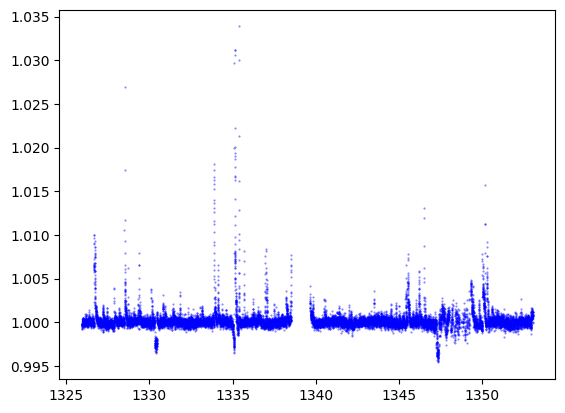

In [3]:
plt.plot(t_setor1, residuo_setor1, '.', markersize=1, color='blue', alpha=0.5, label='Setor 1')
plt.show()

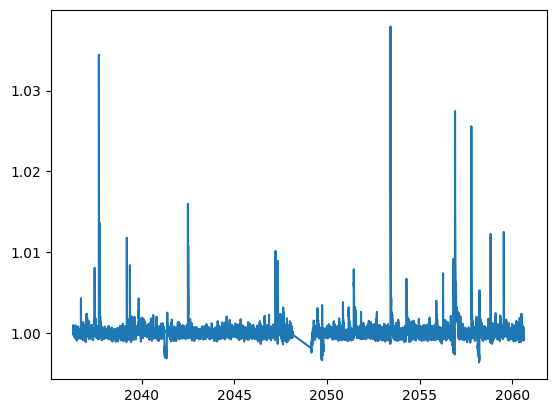

In [4]:
plt.plot(t_setor27, residuo_setor27)
plt.show() 


In [5]:
t_setor95, residuo_setor95 = np.loadtxt("residuo_setor95.txt", unpack=True)

In [6]:
%matplotlib qt
plt.plot(t_setor95, residuo_setor95)
plt.show() 

In [9]:
# ============================================================
# EXTRAÇÃO DOS TRÂNSITOS AU MIC b A PARTIR DOS 3 SETORES
# ============================================================
%matplotlib qt

# Efeméride de referência (usa a tua NEW/OLD conforme preferir)
P_ref  = 8.4631516
T0_ref = 1330.39046      # BTJD
janela = 0.15            # ±dias em torno do meio do trânsito

setores = [
    ("Setor 1  (2018)", t_setor1,  residuo_setor1),
    ("Setor 27 (2020)", t_setor27, residuo_setor27),
    ("Setor 95 (2025)", t_setor95, residuo_setor95),
]

trechos = []
for origem, t_s, r_s in setores:
    # épocas possíveis dentro do intervalo desse setor
    n_min = int(np.floor((t_s.min() - T0_ref) / P_ref))
    n_max = int(np.ceil ((t_s.max() - T0_ref) / P_ref))

    for epoch in range(n_min, n_max + 1):
        Tc = T0_ref + epoch * P_ref
        mask = (t_s >= Tc - janela) & (t_s <= Tc + janela)
        if mask.sum() < 20:          # descarta trânsito faltando (gap/borda)
            continue
        trechos.append({
            't'     : t_s[mask],
            'flux'  : r_s[mask],
            'epoch' : epoch,
            'origem': origem,
        })

trechos.sort(key=lambda x: x['epoch'])
print(f"Total de trânsitos recuperados: {len(trechos)}")
for tr in trechos:
    print(f"  Época {tr['epoch']:>3d}  |  {tr['origem']}  |  {len(tr['t'])} pontos")

# ============================================================
# VISUALIZAÇÃO: trânsitos sobrepostos (entrada do MCMC)
# ============================================================
def fase_dias(t_arr, T0, P):
    ph = ((t_arr - T0) / P + 0.5) % 1 - 0.5   # fase em [-0.5, 0.5]
    return ph * P                              # de volta para dias

fig, ax = plt.subplots(figsize=(9, 6))
cores = plt.cm.viridis(np.linspace(0, 0.9, len(trechos)))

for i, tr in enumerate(trechos):
    t_rel = fase_dias(tr['t'], T0_ref, P_ref)
    ax.plot(t_rel, tr['flux'], 'o', ms=3, alpha=0.5, color=cores[i],
            label=f"Época {tr['epoch']} — {tr['origem']}")

ax.axvline(0, color='red', ls='-.', alpha=0.6, label='T0 de referência')
ax.set_xlim(-janela, janela)
ax.set_xlabel('Tempo relativo a T0 (dias)')
ax.set_ylabel('Fluxo Residual')
ax.set_title(f'AU Mic b — {len(trechos)} trânsitos sobrepostos (pré-MCMC)\n'
             f'T0={T0_ref:.6f}   P={P_ref:.6f} d', fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc='lower right')
plt.tight_layout()
plt.show()

Total de trânsitos recuperados: 7
  Época   0  |  Setor 1  (2018)  |  208 pontos
  Época   2  |  Setor 1  (2018)  |  193 pontos
  Época  84  |  Setor 27 (2020)  |  216 pontos
  Época  85  |  Setor 27 (2020)  |  216 pontos
  Época  86  |  Setor 27 (2020)  |  216 pontos
  Época 302  |  Setor 95 (2025)  |  216 pontos
  Época 304  |  Setor 95 (2025)  |  216 pontos


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import batman
import emcee

print("\n" + "="*60)
print("AJUSTE DE EFEMÉRIDE (T0, P) + TRÂNSITOS SEPARADOS — AU Mic b")
print("="*60)

# ============================================================
# 1. PARÂMETROS
# ============================================================
transitos_conhecidos_b = {
    0:  {'tc': 1330.39046, 'err': 0.00016},
    2:  {'tc': 1347.31646, 'err': 0.00016},
    84: {'tc': 2041.28238, 'err': 0.00026},
    85: {'tc': 2049.74538, 'err': 0.00026},
    86: {'tc': 2058.20838, 'err': 0.00026},
    302: {'tc': 3886.26584, 'err': 0.00051},
    304: {'tc': 3903.18781, 'err': 0.00164},
    
}

# ============================================================
# 1. PARÂMETROS
# ============================================================
# ... [mantenha o dicionário transitos_conhecidos_b igual] ...

T0_pri, T0_pri_err = 1330.39051, 0.001      # Margem um pouco mais folgada
P_pri,  P_pri_err  = 8.46321,  0.0004     # <-- ATUALIZADO: Periodo inicial melhor e prior mais relaxado
RP_b, A_b, INC_b = 0.0496, 19.1, 89.5       # FIXOS
LDC = [0.13, 0.58]

def modelo_TP(t_arr, T0, P):
    p = batman.TransitParams()
    p.t0, p.per, p.rp, p.a, p.inc = T0, P, RP_b, A_b, INC_b
    p.ecc, p.w, p.u, p.limb_dark = 0.0, 90.0, LDC, "quadratic"
    return batman.TransitModel(p, t_arr).light_curve(p)

# ============================================================
# 2. EXTRAÇÃO DOS TRÂNSITOS A PARTIR DOS 3 SETORES
# ============================================================
P_ref  = 8.4631516
T0_ref = 1330.39051      # BTJD

setores = [
    ("Setor 1  (2018)", t_setor1,  residuo_setor1),
    ("Setor 27 (2020)", t_setor27, residuo_setor27),
    ("Setor 95 (2025)", t_setor95, residuo_setor95),
]

trechos = []
for origem, t_s, r_s in setores:
    n_min = int(np.floor((t_s.min() - T0_ref) / P_ref))
    n_max = int(np.ceil ((t_s.max() - T0_ref) / P_ref))
    for epoch in range(n_min, n_max + 1):
        Tc = T0_ref + epoch * P_ref
        mask = (t_s >= Tc - 0.25) & (t_s <= Tc + 0.25)
        if mask.sum() < 20:          # descarta trânsito parcial (gap/borda)
            continue
        trechos.append({'epoch': epoch, 't': t_s[mask],
                        'flux': r_s[mask], 'origem': origem})

trechos.sort(key=lambda x: x['epoch'])

if len(trechos) == 0:
    raise RuntimeError("Nenhum trânsito encontrado.")

print(f"Encontrados {len(trechos)} trânsitos")
for tr in trechos:
    print(f"  Época {tr['epoch']:>3d}  |  {tr['origem']}  |  {len(tr['t'])} pontos")

t_all    = np.concatenate([tr['t']    for tr in trechos])
flux_all = np.concatenate([tr['flux'] for tr in trechos])
sigma    = np.std(flux_all - np.median(flux_all))
print(f"Total: {len(t_all)} pontos em {len(trechos)} trânsitos\n")

# ============================================================
# 3. MCMC — SÓ T0 E P
# ============================================================
def log_prob(theta):
    T0, P = theta
    if not (T0_pri - 0.02 < T0 < T0_pri + 0.02): return -np.inf
    if not (P_pri  - 0.01 < P  < P_pri  + 0.01): return -np.inf
    lp  = -0.5 * ((T0 - T0_pri) / T0_pri_err)**2
    lp += -0.5 * ((P  - P_pri ) / P_pri_err )**2
    try:
        modelo = modelo_TP(t_all, T0, P)
        lnL = -0.5 * np.sum(((flux_all - modelo) / sigma)**2)
    except Exception:
        return -np.inf
    return lp + lnL

nwalkers, ndim, nsteps = 64, 2, 150
p0 = np.array([T0_pri, P_pri]) + np.array([1e-5, 1e-6]) * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
print(f"MCMC: {nwalkers} walkers × {nsteps} steps")
print("Rodando...")
sampler.run_mcmc(p0, nsteps, progress=True)

try:
    tau = sampler.get_autocorr_time(quiet=True)
    discard = int(2 * np.max(tau))
    thin    = max(int(0.5 * np.min(tau)), 1)
    print(f"\nAutocorr: T0={tau[0]:.0f}  P={tau[1]:.0f}")
except Exception:
    discard, thin = 2000, 15

samples = sampler.get_chain(discard=discard, thin=thin, flat=True)
T0_fit, P_fit = np.median(samples, axis=0)
T0_err, P_err = np.std(samples, axis=0)

print("\n" + "="*60)
print("EFEMÉRIDE REFINADA (MCMC)")
print("="*60)
print(f"T0 = {T0_fit:.6f} ± {T0_err:.6f}   (prior: {T0_pri:.6f} ± {T0_pri_err:.6f})")
print(f"P  = {P_fit:.6f} ± {P_err:.6f}   (prior: {P_pri:.6f} ± {P_pri_err:.6f})")
print("="*60)

# ============================================================
# 4. TRÂNSITOS SEPARADOS (grid) COM EFEMÉRIDE NOVA
# ============================================================
%matplotlib qt

n = len(trechos)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.5), sharey=True)
if n == 1: axes = [axes]

print(f"\n{'Época':<8} {'T_c novo (efeméride)':<24} {'Origem':<12}")
print("-"*50)

for i, tr in enumerate(trechos):
    ax = axes[i]
    epoch = tr['epoch']

    # T_c pela EFEMÉRIDE NOVA
    tc_novo = T0_fit + epoch * P_fit

    # Modelo com a efeméride nova (batman é periódico, acerta a época sozinho)
    t_denso = np.linspace(tr['t'].min(), tr['t'].max(), 400)
    modelo_denso = modelo_TP(t_denso, T0_fit, P_fit)

    # Plot
    ax.plot(tr['t'], tr['flux'], 'k.', ms=3, alpha=0.4, label='Dados')
    ax.plot(t_denso, modelo_denso, 'r-', lw=2.5, label='Efeméride nova')
    ax.axvline(tc_novo, color='red', ls='--', alpha=0.6)

    cor = 'blue' if 'Teór' in tr['origem'] else 'black'
    ax.set_title(f"Época {epoch}\n$T_c$ = {tc_novo:.5f}", fontsize=10, color=cor)
    ax.set_xlabel('Tempo [BTJD]')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.set_ylabel('Fluxo Residual')
        ax.legend(fontsize=8)

    print(f"{epoch:<8} {tc_novo:<24.6f} {tr['origem']:<12}")

print("="*50)

plt.suptitle(f'AU Mic b — Trânsitos individuais com efeméride nova\n'
             f'T0={T0_fit:.6f}±{T0_err:.6f}   P={P_fit:.6f}±{P_err:.6f} d',
             fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# ============================================================
# 5. CORNER PLOT (opcional)
# ============================================================
try:
    import corner
    corner.corner(samples, labels=[r"$T_0$", r"$P$"],
                  truths=[T0_pri, P_pri], quantiles=[0.16, 0.5, 0.84],
                  show_titles=True, title_fmt='.6f')
    plt.show()
except ImportError:
    print("\n(pip install corner --break-system-packages para o corner plot)")


AJUSTE DE EFEMÉRIDE (T0, P) + TRÂNSITOS SEPARADOS — AU Mic b
Encontrados 7 trânsitos
  Época   0  |  Setor 1  (2018)  |  352 pontos
  Época   2  |  Setor 1  (2018)  |  307 pontos
  Época  84  |  Setor 27 (2020)  |  360 pontos
  Época  85  |  Setor 27 (2020)  |  360 pontos
  Época  86  |  Setor 27 (2020)  |  360 pontos
  Época 302  |  Setor 95 (2025)  |  359 pontos
  Época 304  |  Setor 95 (2025)  |  360 pontos
Total: 2458 pontos em 7 trânsitos

MCMC: 64 walkers × 150 steps
Rodando...


 42%|████▏     | 63/150 [00:05<00:06, 13.17it/s]Traceback (most recent call last):
  File "c:\Users\paola\AppData\Local\Programs\Python\Python312\Lib\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\paola\AppData\Local\Temp\ipykernel_25236\3814435685.py", line 89, in log_prob
    lnL = -0.5 * np.sum(((flux_all - modelo) / sigma)**2)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\paola\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py", line 2333, in _sum_dispatcher
    def _sum_dispatcher(a, axis=None, dtype=None, out=None, keepdims=None,
    
KeyboardInterrupt
 43%|████▎     | 64/150 [00:05<00:07, 11.90it/s]


emcee: Exception while calling your likelihood function:
  params: [1330.3890119     8.46315052]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import batman
import emcee
import os


print("\n" + "="*60)
print("AJUSTE DE EFEMÉRIDE (T0, P) + TRÂNSITOS SEPARADOS — AU Mic b")
print("="*60)

# ============================================================
# 1. PARÂMETROS
# ============================================================
transitos_conhecidos_b = {
    0:  {'tc': 1330.39046, 'err': 0.00016},
    2:  {'tc': 1347.31646, 'err': 0.00016},
    84: {'tc': 2041.28238, 'err': 0.00026},
    85: {'tc': 2049.74538, 'err': 0.00026},
    86: {'tc': 2058.20838, 'err': 0.00026},
    302: {'tc': 3886.26584, 'err': 0.00051},
    304: {'tc': 3903.18781, 'err': 0.00164},
    
}

# ============================================================
# 1. PARÂMETROS
# ============================================================
# ... [mantenha o dicionário transitos_conhecidos_b igual] ...

T0_pri, T0_pri_err = 1330.39051, 0.001      # Margem um pouco mais folgada
P_pri,  P_pri_err  = 8.46321,  0.0004     # <-- ATUALIZADO: Periodo inicial melhor e prior mais relaxado
RP_b, A_b, INC_b = 0.0496, 19.1, 89.5       # FIXOS
LDC = [0.13, 0.58]

def modelo_TP(t_arr, T0, P):
    p = batman.TransitParams()
    p.t0, p.per, p.rp, p.a, p.inc = T0, P, RP_b, A_b, INC_b
    p.ecc, p.w, p.u, p.limb_dark = 0.0, 90.0, LDC, "quadratic"
    return batman.TransitModel(p, t_arr).light_curve(p)

# ============================================================
# 2. EXTRAÇÃO DOS TRÂNSITOS A PARTIR DOS 3 SETORES
# ============================================================
P_ref  = 8.4631516
T0_ref = 1330.39051      # BTJD

setores = [
    ("Setor 1  (2018)", t_setor1,  residuo_setor1),
    ("Setor 27 (2020)", t_setor27, residuo_setor27),
    ("Setor 95 (2025)", t_setor95, residuo_setor95),
]

trechos = []
for origem, t_s, r_s in setores:
    n_min = int(np.floor((t_s.min() - T0_ref) / P_ref))
    n_max = int(np.ceil ((t_s.max() - T0_ref) / P_ref))
    for epoch in range(n_min, n_max + 1):
        Tc = T0_ref + epoch * P_ref
        mask = (t_s >= Tc - 0.25) & (t_s <= Tc + 0.25)
        if mask.sum() < 20:          # descarta trânsito parcial (gap/borda)
            continue
        trechos.append({'epoch': epoch, 't': t_s[mask],
                        'flux': r_s[mask], 'origem': origem})

trechos.sort(key=lambda x: x['epoch'])

if len(trechos) == 0:
    raise RuntimeError("Nenhum trânsito encontrado.")

print(f"Encontrados {len(trechos)} trânsitos")
for tr in trechos:
    print(f"  Época {tr['epoch']:>3d}  |  {tr['origem']}  |  {len(tr['t'])} pontos")

t_all    = np.concatenate([tr['t']    for tr in trechos])
flux_all = np.concatenate([tr['flux'] for tr in trechos])
sigma    = np.std(flux_all - np.median(flux_all))
print(f"Total: {len(t_all)} pontos em {len(trechos)} trânsitos\n")

import os

# ============================================================
# 3. MCMC — SÓ T0 E P  (roda uma vez, depois carrega do disco)
# ============================================================
# ============================================================
# MCMC com cache completo (salva TUDO para plotar depois)
# ============================================================
arquivo_mcmc = "mcmc_auMic_b_ephx1.npz"

if os.path.exists(arquivo_mcmc):
    print(f"Carregando MCMC salvo: {arquivo_mcmc}  (não re-roda o sampler)")
    d = np.load(arquivo_mcmc)
    samples     = d["samples"]
    chain_full  = d["chain_full"]  if "chain_full"  in d.files else None
    logprob_full= d["logprob_full"] if "logprob_full" in d.files else None
    discard     = int(d["discard"]) if "discard" in d.files else 0
    thin        = int(d["thin"])    if "thin"    in d.files else 1
    tau         = d["tau"]          if "tau"     in d.files else np.array([np.nan, np.nan])
    nwalkers    = int(d["nwalkers"]) if "nwalkers" in d.files else None
    nsteps      = int(d["nsteps"])   if "nsteps"   in d.files else None
    print(f"  → samples: {samples.shape} | chain_full: "
          f"{None if chain_full is None else chain_full.shape}")
    print(f"  → discard={discard}, thin={thin}, tau={tau}")

else:
    def log_prob(theta):
        T0, P = theta
        if not (T0_pri - 0.02 < T0 < T0_pri + 0.02): return -np.inf
        if not (P_pri  - 0.01 < P  < P_pri  + 0.01): return -np.inf
        lp  = -0.5 * ((T0 - T0_pri) / T0_pri_err)**2
        lp += -0.5 * ((P  - P_pri ) / P_pri_err )**2
        try:
            modelo = modelo_TP(t_all, T0, P)
            lnL = -0.5 * np.sum(((flux_all - modelo) / sigma)**2)
        except Exception:
            return -np.inf
        return lp + lnL

    nwalkers, ndim, nsteps = 64, 2, 40000
    p0 = np.array([T0_pri, P_pri]) + np.array([1e-5, 1e-6]) * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
    print(f"MCMC: {nwalkers} walkers × {nsteps} steps")
    print("Rodando...")
    sampler.run_mcmc(p0, nsteps, progress=True)

    # Diagnóstico de autocorrelação
    try:
        tau = sampler.get_autocorr_time(quiet=True)
        discard = int(2 * np.max(tau))
        thin    = max(int(0.5 * np.min(tau)), 1)
        print(f"\nAutocorr: T0={tau[0]:.0f}  P={tau[1]:.0f}")
    except Exception:
        tau = np.array([np.nan, np.nan])
        discard, thin = 2000, 1000
        print(f"\n(Autocorrelação não convergiu; usando discard={discard}, thin={thin})")

    # Extrai TUDO
    chain_full   = sampler.get_chain()                                  # (nsteps, nwalkers, ndim)
    logprob_full = sampler.get_log_prob()                               # (nsteps, nwalkers)
    samples      = sampler.get_chain(discard=discard, thin=thin, flat=True)  # (N, ndim)

    # Salva TUDO
    np.savez(arquivo_mcmc,
             samples=samples,
             chain_full=chain_full,
             logprob_full=logprob_full,
             discard=discard,
             thin=thin,
             tau=tau,
             nwalkers=nwalkers,
             nsteps=nsteps)
    print(f"MCMC salvo em: {arquivo_mcmc}  "
          f"({os.path.getsize(arquivo_mcmc)/1e6:.1f} MB)")

# ============================================================
# Valores finais (funcionam com cache ou execução nova)
# ============================================================
T0_fit, P_fit = np.median(samples, axis=0)
T0_err, P_err = np.std(samples, axis=0)
T0_16, T0_84  = np.percentile(samples[:, 0], [16, 84])
P_16,  P_84   = np.percentile(samples[:, 1], [16, 84])

print("\n" + "="*60)
print("EFEMÉRIDE REFINADA (MCMC)")
print("="*60)
print(f"T0 = {T0_fit:.6f}  +{T0_84-T0_fit:.6f} -{T0_fit-T0_16:.6f}   (prior: {T0_pri:.6f} ± {T0_pri_err:.6f})")
print(f"P  = {P_fit:.6f}  +{P_84-P_fit:.6f} -{P_fit-P_16:.6f}   (prior: {P_pri:.6f} ± {P_pri_err:.6f})")
print("="*60)

# ============================================================
# 4. TRÂNSITOS SEPARADOS (grid) COM EFEMÉRIDE NOVA
# ============================================================
%matplotlib qt

n = len(trechos)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.5), sharey=True)
if n == 1: axes = [axes]

print(f"\n{'Época':<8} {'T_c novo (efeméride)':<24} {'Origem':<12}")
print("-"*50)

for i, tr in enumerate(trechos):
    ax = axes[i]
    epoch = tr['epoch']

    # T_c pela EFEMÉRIDE NOVA
    tc_novo = T0_fit + epoch * P_fit

    # Modelo com a efeméride nova (batman é periódico, acerta a época sozinho)
    t_denso = np.linspace(tr['t'].min(), tr['t'].max(), 400)
    modelo_denso = modelo_TP(t_denso, T0_fit, P_fit)

    # Plot
    ax.plot(tr['t'], tr['flux'], 'k.', ms=3, alpha=0.4, label='Dados')
    ax.plot(t_denso, modelo_denso, 'r-', lw=2.5, label='Efeméride nova')
    ax.axvline(tc_novo, color='red', ls='--', alpha=0.6)

    cor = 'blue' if 'Teór' in tr['origem'] else 'black'
    ax.set_title(f"Época {epoch}\n$T_c$ = {tc_novo:.5f}", fontsize=10, color=cor)
    ax.set_xlabel('Tempo [BTJD]')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.set_ylabel('Fluxo Residual')
        ax.legend(fontsize=8)

    print(f"{epoch:<8} {tc_novo:<24.6f} {tr['origem']:<12}")

print("="*50)

plt.suptitle(f'AU Mic b — Trânsitos individuais com efeméride nova\n'
             f'T0={T0_fit:.6f}±{T0_err:.6f}   P={P_fit:.6f}±{P_err:.6f} d',
             fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# ============================================================
# 5. CORNER PLOT (opcional)
# ============================================================
try:
    import corner
    corner.corner(samples, labels=[r"$T_0$", r"$P$"],
                  truths=[T0_pri, P_pri], quantiles=[0.16, 0.5, 0.84],
                  show_titles=True, title_fmt='.6f')
    plt.show()
except ImportError:
    print("\n(pip install corner --break-system-packages para o corner plot)")


AJUSTE DE EFEMÉRIDE (T0, P) + TRÂNSITOS SEPARADOS — AU Mic b
Encontrados 7 trânsitos
  Época   0  |  Setor 1  (2018)  |  352 pontos
  Época   2  |  Setor 1  (2018)  |  307 pontos
  Época  84  |  Setor 27 (2020)  |  360 pontos
  Época  85  |  Setor 27 (2020)  |  360 pontos
  Época  86  |  Setor 27 (2020)  |  360 pontos
  Época 302  |  Setor 95 (2025)  |  359 pontos
  Época 304  |  Setor 95 (2025)  |  360 pontos
Total: 2458 pontos em 7 trânsitos

MCMC: 64 walkers × 40000 steps
Rodando...


100%|██████████| 40000/40000 [29:15<00:00, 22.78it/s]  



Autocorr: T0=34  P=32
MCMC salvo em: mcmc_auMic_b_ephx1.npz  (64.2 MB)

EFEMÉRIDE REFINADA (MCMC)
T0 = 1330.386419  +0.000712 -0.000726   (prior: 1330.390510 ± 0.001000)
P  = 8.463157  +0.000005 -0.000005   (prior: 8.463210 ± 0.000400)

Época    T_c novo (efeméride)     Origem      
--------------------------------------------------
0        1330.386419              Setor 1  (2018)
2        1347.312732              Setor 1  (2018)
84       2041.291573              Setor 27 (2020)
85       2049.754730              Setor 27 (2020)
86       2058.217886              Setor 27 (2020)
302      3886.259712              Setor 95 (2025)
304      3903.186026              Setor 95 (2025)


In [21]:
import os

# ============================================================
# 3. MCMC — SÓ T0 E P  (roda uma vez, depois carrega do disco)
# ============================================================
arquivo_mcmc = "mcmc_auMic_b_ephx1.npz"

if os.path.exists(arquivo_mcmc):
    print(f"Carregando MCMC salvo: {arquivo_mcmc}  (não re-roda o sampler)")
    d = np.load(arquivo_mcmc)
    samples = d["samples"]
else:
    def log_prob(theta):
        T0, P = theta
        if not (T0_pri - 0.02 < T0 < T0_pri + 0.02): return -np.inf
        if not (P_pri  - 0.01 < P  < P_pri  + 0.01): return -np.inf
        lp  = -0.5 * ((T0 - T0_pri) / T0_pri_err)**2
        lp += -0.5 * ((P  - P_pri ) / P_pri_err )**2
        try:
            modelo = modelo_TP(t_all, T0, P)
            lnL = -0.5 * np.sum(((flux_all - modelo) / sigma)**2)
        except Exception:
            return -np.inf
        return lp + lnL

    nwalkers, ndim, nsteps = 64, 2, 150000
    p0 = np.array([T0_pri, P_pri]) + np.array([1e-5, 1e-6]) * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
    print(f"MCMC: {nwalkers} walkers × {nsteps} steps")
    print("Rodando...")
    sampler.run_mcmc(p0, nsteps, progress=True)

    try:
        tau = sampler.get_autocorr_time(quiet=True)
        discard = int(2 * np.max(tau))
        thin    = max(int(0.5 * np.min(tau)), 1)
        print(f"\nAutocorr: T0={tau[0]:.0f}  P={tau[1]:.0f}")
    except Exception:
        discard, thin = 2000, 15

    samples = sampler.get_chain(discard=discard, thin=thin, flat=True)
    np.savez(arquivo_mcmc, samples=samples)
    print(f"MCMC salvo em: {arquivo_mcmc}")

T0_fit, P_fit = np.median(samples, axis=0)
T0_err, P_err = np.std(samples, axis=0)

Carregando MCMC salvo: mcmc_auMic_b_ephx1.npz  (não re-roda o sampler)


In [25]:
fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)
samples_raw = sampler.get_chain()
labels = [r"$T_0$", r"$P$"]

for i in range(2):
    ax = axes[i]
    ax.plot(samples_raw[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.axvline(discard, color='r', linestyle='--', label='Burn-in')

axes[1].set_xlabel("Passos (Steps)")
axes[0].set_title("Trace Plot - Verificação Visual de Convergência")
axes[0].legend()
plt.show()

In [27]:
# ============================================================
# 5. CORNER PLOT COMPLETO (cores padrão, linhas ajustadas)
# ============================================================
%matplotlib qt

try:
    import corner
except ImportError:
    print("pip install corner --break-system-packages")
    corner = None

if corner is not None:
    # Estatísticas
    T0_16, T0_50, T0_84 = np.percentile(samples[:, 0], [16, 50, 84])
    P_16,  P_50,  P_84  = np.percentile(samples[:, 1], [16, 50, 84])

    labels = [r"$T_0$ (BTJD)", r"$P$ (dias)"]

    fig = corner.corner(
        samples,
        labels=labels,
        truths=[T0_pri, P_pri],            # prior (linha padrão azul)
        quantiles=[0.16, 0.5, 0.84],       # tracejadas nos histogramas
        show_titles=True,
        title_fmt='.6f',
        title_kwargs={'fontsize': 11},
        label_kwargs={'fontsize': 12},
        levels=(0.393, 0.865, 0.989),      # 1σ, 2σ, 3σ
        smooth=1.0,
        bins=40
    )

    axes = np.array(fig.axes).reshape((2, 2))
    medianas = [T0_50, P_50]
    lo = [T0_16, P_16]
    hi = [T0_84, P_84]

    # --- Diagonais: linha da mediana (sólida) + percentis 16/84 (tracejadas) ---
    for i in range(2):
        ax = axes[i, i]
        ax.axvline(medianas[i], color='red', lw=1.6)               # mediana
        ax.axvline(lo[i], color='gray', ls='--', lw=1.2)           # 16%
        ax.axvline(hi[i], color='gray', ls='--', lw=1.2)           # 84%

    # --- Painel 2D (inferior esquerdo): cruz da mediana + ponto do prior ---
    ax2d = axes[1, 0]
    ax2d.axvline(T0_50, color='red', lw=1.2, alpha=0.7)
    ax2d.axhline(P_50,  color='red', lw=1.2, alpha=0.7)
    ax2d.plot(T0_50, P_50, 's', color='red', ms=7)                 # mediana
    ax2d.plot(T0_pri, P_pri, '*', color='dodgerblue', ms=14)       # prior

    # --- Legenda no painel vazio (superior direito) ---
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], color='red', lw=1.8, label='Mediana'),
        Line2D([0], [0], color='gray', ls='--', lw=1.2, label='16 / 84 %'),
        Line2D([0], [0], marker='*', color='dodgerblue', lw=0, ms=12, label='Prior'),
    ]
    axes[0, 1].legend(handles=handles, loc='center', fontsize=10, frameon=True)
    axes[0, 1].axis('off')

    # Correlação
    corr = np.corrcoef(samples[:, 0], samples[:, 1])[0, 1]

    fig.suptitle(
        f"AU Mic b — Posterior MCMC (Efeméride)\n"
        f"$T_0$ = {T0_50:.6f}$^{{+{T0_84-T0_50:.6f}}}_{{-{T0_50-T0_16:.6f}}}$   |   "
        f"$P$ = {P_50:.6f}$^{{+{P_84-P_50:.6f}}}_{{-{P_50-P_16:.6f}}}$ d   |   "
        f"ρ(T0,P) = {corr:+.2f}",
        fontsize=12, y=1.02
    )

    plt.tight_layout()
    plt.show()

    # Resumo textual
    print("\n" + "="*70)
    print("RESUMO DA POSTERIOR")
    print("="*70)
    print(f"{'Parâmetro':<14} {'Mediana':<16} {'+σ':<14} {'-σ':<14}")
    print("-"*70)
    print(f"{'T0 (BTJD)':<14} {T0_50:<16.6f} {T0_84-T0_50:<14.6f} {T0_50-T0_16:<14.6f}")
    print(f"{'P (dias)':<14} {P_50:<16.6f} {P_84-P_50:<14.6f} {P_50-P_16:<14.6f}")
    print("-"*70)
    print(f"Correlação ρ(T0, P): {corr:+.3f}")
    print(f"Amostras: {len(samples)}")
    print("="*70)


RESUMO DA POSTERIOR
Parâmetro      Mediana          +σ             -σ            
----------------------------------------------------------------------
T0 (BTJD)      1330.386419      0.000712       0.000726      
P (dias)       8.463157         0.000005       0.000005      
----------------------------------------------------------------------
Correlação ρ(T0, P): -0.517
Amostras: 170368


In [23]:
%matplotlib qt

# ============================================================
# GRÁFICO: 7 trânsitos empilhados com a efeméride nova
# ============================================================
fig, ax = plt.subplots(figsize=(9, 11))

offset_step = 0.006   # espaçamento vertical entre trânsitos
cores = plt.cm.viridis(np.linspace(0, 0.9, len(trechos)))

for i, tr in enumerate(trechos):
    epoch = tr['epoch']
    off = i * offset_step

    # T_c da efeméride nova
    tc_novo = T0_fit + epoch * P_fit

    # Tempo relativo ao próprio T_c (centra cada trânsito em zero)
    t_rel = tr['t'] - tc_novo

    # Modelo denso da efeméride nova, também centrado
    t_denso = np.linspace(tr['t'].min(), tr['t'].max(), 400)
    modelo_denso = modelo_TP(t_denso, T0_fit, P_fit)
    t_denso_rel = t_denso - tc_novo

    # Dados + modelo com offset
    ax.plot(t_rel * 24, tr['flux'] + off, 'o', ms=3, alpha=0.4, color=cores[i])
    ax.plot(t_denso_rel * 24, modelo_denso + off, '-', lw=2, color='crimson', zorder=50)

    # Linha do T_c (centro do trânsito = 0)
    ax.axvline(0, color='gray', ls=':', lw=0.8, alpha=0.5)

    # Rótulo de cada época
    cor_txt = 'blue' if 'Teór' in tr['origem'] else 'black'
    ax.text(6.3, 1 + off, f"Época {epoch}\n{tr['origem'][:10]}",
            fontsize=8, va='center', color=cor_txt)
    ax.text(-6.3, 1 + off, f"$T_c$={tc_novo:.4f}",
            fontsize=7, va='center', ha='left', color=cor_txt, alpha=0.8)

ax.set_xlabel('Tempo relativo ao $T_c$ (horas)', fontweight='bold')
ax.set_ylabel('Fluxo Normalizado (com offset)', fontweight='bold')
ax.set_title(f'AU Mic b — {len(trechos)} Trânsitos com Efeméride Nova\n'
             f'T0 = {T0_fit:.6f} ± {T0_err:.6f}   |   '
             f'P = {P_fit:.6f} ± {P_err:.6f} d',
             fontweight='bold', fontsize=11)
ax.set_xlim(-8, 9)
ax.set_ylim(1 - 3*offset_step, 1 + len(trechos)*offset_step + 3*offset_step)
ax.grid(alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

In [14]:
fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)
samples_raw = sampler.get_chain()
labels = [r"$T_0$", r"$P$"]

for i in range(2):
    ax = axes[i]
    ax.plot(samples_raw[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.axvline(discard, color='r', linestyle='--', label='Burn-in')

axes[1].set_xlabel("Passos (Steps)")
axes[0].set_title("Trace Plot - Verificação Visual de Convergência")
axes[0].legend()
plt.show()

NameError: name 'discard' is not defined

In [16]:
%matplotlib qt

# ============================================================
# GRÁFICO: 7 trânsitos empilhados com a efeméride nova
# ============================================================
fig, ax = plt.subplots(figsize=(9, 11))

offset_step = 0.006   # espaçamento vertical entre trânsitos
cores = plt.cm.viridis(np.linspace(0, 0.9, len(trechos)))

for i, tr in enumerate(trechos):
    epoch = tr['epoch']
    off = i * offset_step

    # T_c da efeméride nova
    tc_novo = T0_fit + epoch * P_fit

    # Tempo relativo ao próprio T_c (centra cada trânsito em zero)
    t_rel = tr['t'] - tc_novo

    # Modelo denso da efeméride nova, também centrado
    t_denso = np.linspace(tr['t'].min(), tr['t'].max(), 400)
    modelo_denso = modelo_TP(t_denso, T0_fit, P_fit)
    t_denso_rel = t_denso - tc_novo

    # Dados + modelo com offset
    ax.plot(t_rel * 24, tr['flux'] + off, 'o', ms=3, alpha=0.4, color=cores[i])
    ax.plot(t_denso_rel * 24, modelo_denso + off, '-', lw=2, color='crimson', zorder=50)

    # Linha do T_c (centro do trânsito = 0)
    ax.axvline(0, color='gray', ls=':', lw=0.8, alpha=0.5)

    # Rótulo de cada época
    cor_txt = 'blue' if 'Teór' in tr['origem'] else 'black'
    ax.text(6.3, 1 + off, f"Época {epoch}\n{tr['origem'][:10]}",
            fontsize=8, va='center', color=cor_txt)
    ax.text(-6.3, 1 + off, f"$T_c$={tc_novo:.4f}",
            fontsize=7, va='center', ha='left', color=cor_txt, alpha=0.8)

ax.set_xlabel('Tempo relativo ao $T_c$ (horas)', fontweight='bold')
ax.set_ylabel('Fluxo Normalizado (com offset)', fontweight='bold')
ax.set_title(f'AU Mic b — {len(trechos)} Trânsitos com Efeméride Nova\n'
             f'T0 = {T0_fit:.6f} ± {T0_err:.6f}   |   '
             f'P = {P_fit:.6f} ± {P_err:.6f} d',
             fontweight='bold', fontsize=11)
ax.set_xlim(-8, 9)
ax.set_ylim(1 - 3*offset_step, 1 + len(trechos)*offset_step + 3*offset_step)
ax.grid(alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

In [15]:
t_95, f_95 = np.loadtxt("lc_setor95.txt", unpack=True)

In [16]:
plt.plot(t_95, f_95, '.', markersize=1, color='blue', alpha=0.5)
plt.show()

In [17]:
# ============================================================
# COMPARAÇÃO EFEMÉRIDE OLD VS NOVA — AU Mic b (com erros de T0)
# ============================================================
%matplotlib qt

import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("COMPARAÇÃO DAS EFEMÉRIDES AU Mic b")
print("="*70)

# ============================================================
# EFEMÉRIDES
# ============================================================
# OLD
T0_old, erro_T0_old = 1330.39051, 0.00016
P_old = 8.4631516

# NOVA
T0_new, erro_T0_new = 1330.386418, 0.000724
P_new = 8.463157

print("\nEFEMÉRIDE OLD")
print("-"*40)
print(f"T0 = {T0_old:.6f} ± {erro_T0_old:.6f} BTJD")
print(f"P  = {P_old:.7f} dias")
print(f"Erro T0 = {erro_T0_old*24*60:.2f} minutos")

print("\nEFEMÉRIDE NOVA")
print("-"*40)
print(f"T0 = {T0_new:.6f} ± {erro_T0_new:.6f} BTJD")
print(f"P  = {P_new:.7f} dias")
print(f"Erro T0 = {erro_T0_new*24*60:.2f} minutos")

delta = (T0_old - T0_new) * 24 * 60
print(f"\nDiferença entre T0: {delta:.2f} minutos")

# ============================================================
# DADOS POR SETOR
#   Setores 1 e 27 -> t_todos / f_todos
#   Setor 95       -> t_95 / f_95
# ============================================================
t_setores = [t_todos[0], t_todos[1], t_95]
f_setores = [f_todos[0], f_todos[1], f_95]

setor_nomes = ["Setor 1 (2018)", "Setor 27 (2020)", "Setor 95 (2025)"]

tempo_min = np.min([np.min(t) for t in t_setores])
tempo_max = np.max([np.max(t) for t in t_setores])

# ============================================================
# TRÂNSITOS PREVISTOS
# ============================================================
ep_old = np.arange(int(np.floor((tempo_min - T0_old) / P_old)),
                   int(np.ceil ((tempo_max - T0_old) / P_old)) + 1)
trans_old = T0_old + ep_old * P_old

ep_new = np.arange(int(np.floor((tempo_min - T0_new) / P_new)),
                   int(np.ceil ((tempo_max - T0_new) / P_new)) + 1)
trans_new = T0_new + ep_new * P_new

print("\n" + "="*70)
print("TRÂNSITOS PREVISTOS")
print("="*70)

print("\nOLD")
for e, tc in zip(ep_old, trans_old):
    print(f"Época {e:4d}  {tc:.6f} BTJD")

print("\nNOVA")
for e, tc in zip(ep_new, trans_new):
    print(f"Época {e:4d}  {tc:.6f} BTJD")

# ============================================================
# FIGURA
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, (t_sec, f_sec) in enumerate(zip(t_setores, f_setores)):
    ax = axes[i]

    # dados
    ax.plot(t_sec, f_sec, 'k.', markersize=2, alpha=0.5, label="Dados TESS")

    # ---- OLD ----
    first_old = True
    for e, tr in zip(ep_old, trans_old):
        if t_sec[0] <= tr <= t_sec[-1]:
            ax.axvline(tr, color='blue', ls='--', lw=1.8,
                       label="Efeméride OLD" if first_old else None)
            ax.axvspan(tr - erro_T0_old, tr + erro_T0_old, color='blue', alpha=0.15,
                       label="Erro OLD (1σ)" if first_old else None)
            ax.text(tr, np.nanmax(f_sec), f"E{e}", color="blue", rotation=90, fontsize=8)
            first_old = False

    # ---- NOVA ----
    first_new = True
    for e, tr in zip(ep_new, trans_new):
        if t_sec[0] <= tr <= t_sec[-1]:
            ax.axvline(tr, color='red', ls='-', lw=1.8,
                       label="Efeméride NOVA" if first_new else None)
            ax.axvspan(tr - erro_T0_new, tr + erro_T0_new, color='red', alpha=0.15,
                       label="Erro NOVA (1σ)" if first_new else None)
            ax.text(tr, np.nanmin(f_sec), f"E{e}", color="red", rotation=90, fontsize=8)
            first_new = False

    # ---- formatação ----
    ax.set_title(setor_nomes[i], fontsize=13, fontweight='bold')
    ax.set_ylabel("Fluxo normalizado")
    ax.grid(alpha=0.3, ls=":")
    ax.legend(fontsize=9, loc="best")

axes[-1].set_xlabel("Tempo [BTJD]", fontsize=12)

plt.suptitle("AU Mic b — Comparação Efeméride OLD vs NOVA\n"
             "Azul = OLD | Vermelho = NOVA",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✓ Comparação finalizada!")


COMPARAÇÃO DAS EFEMÉRIDES AU Mic b

EFEMÉRIDE OLD
----------------------------------------
T0 = 1330.390510 ± 0.000160 BTJD
P  = 8.4631516 dias
Erro T0 = 0.23 minutos

EFEMÉRIDE NOVA
----------------------------------------
T0 = 1330.386418 ± 0.000724 BTJD
P  = 8.4631570 dias
Erro T0 = 1.04 minutos

Diferença entre T0: 5.89 minutos

TRÂNSITOS PREVISTOS

OLD
Época   -1  1321.927358 BTJD
Época    0  1330.390510 BTJD
Época    1  1338.853662 BTJD
Época    2  1347.316813 BTJD
Época    3  1355.779965 BTJD
Época    4  1364.243116 BTJD
Época    5  1372.706268 BTJD
Época    6  1381.169420 BTJD
Época    7  1389.632571 BTJD
Época    8  1398.095723 BTJD
Época    9  1406.558874 BTJD
Época   10  1415.022026 BTJD
Época   11  1423.485178 BTJD
Época   12  1431.948329 BTJD
Época   13  1440.411481 BTJD
Época   14  1448.874632 BTJD
Época   15  1457.337784 BTJD
Época   16  1465.800936 BTJD
Época   17  1474.264087 BTJD
Época   18  1482.727239 BTJD
Época   19  1491.190390 BTJD
Época   20  1499.653542 BTJD
É


✓ Comparação finalizada!
